# 04 - E91 con Eve e sorgente classica


Confronto tra tre scenari del protocollo E91.

Il caso ideale usa coppie entangled condivise tra Alice e Bob. L'attacco intercept-resend di Eve rompe o degrada le correlazioni quantistiche. Una sorgente classicamente correlata può generare correlazioni nei bit, ma non deve produrre una violazione CHSH robusta.

Il confronto usa due indicatori: il QBER sulla chiave sifted e il parametro CHSH `S`.

## Setup

Import dei moduli del progetto e cartelle per tabelle e figure.

In [1]:
from pathlib import Path
import sys

import pandas as pd
import matplotlib.pyplot as plt

current_path = Path.cwd()

if (current_path / "src" / "e91.py").exists():
    project_root = current_path
else:
    project_root = current_path.parent

src_path = project_root / "src"

if str(src_path) not in sys.path:
    sys.path.append(str(src_path))

from e91 import (
    run_e91_protocol,
    run_e91_protocol_with_eve,
    run_e91_protocol_with_classical_source,
    run_chsh_experiment,
    run_chsh_experiment_with_eve,
    run_chsh_experiment_with_classical_source,
)
from qkd_core import sift_keys, compute_qber
from metrics import (
    QBER_THRESHOLD_BB84,
    CHSH_CLASSICAL_LIMIT,
    CHSH_TSIRELSON_BOUND,
    compute_sifted_key_length,
    compute_sifted_key_rate,
    decide_qber_acceptance,
)

tables_dir = project_root / "results" / "tables"
figures_dir = project_root / "results" / "figures"

tables_dir.mkdir(parents=True, exist_ok=True)
figures_dir.mkdir(parents=True, exist_ok=True)

print("Setup completato.")

Setup completato.


## Parametri

Impostiamo il numero di round, gli shot CHSH, il seed e le probabilità di intercettazione di Eve.

In [2]:
N_ROUNDS = 1000
SHOTS_CHSH = 2000
SEED = 42
INTERCEPT_PROBABILITIES = [0.0, 0.25, 0.5, 0.75, 1.0]
QBER_THRESHOLD = QBER_THRESHOLD_BB84

print("Numero di round:", N_ROUNDS)
print("Shot CHSH:", SHOTS_CHSH)
print("Seed:", SEED)
print("Probabilità di intercettazione:", INTERCEPT_PROBABILITIES)
print("Soglia QBER:", QBER_THRESHOLD)

Numero di round: 1000
Shot CHSH: 2000
Seed: 42
Probabilità di intercettazione: [0.0, 0.25, 0.5, 0.75, 1.0]
Soglia QBER: 0.11


## Scenario E91 ideale

E91 ideale: chiave sifted, QBER e test CHSH.

In [3]:
results_ideal = run_e91_protocol(N_ROUNDS, seed=SEED)

alice_key_ideal, bob_key_ideal = sift_keys(results_ideal)
qber_ideal = compute_qber(alice_key_ideal, bob_key_ideal)
sifted_key_length_ideal = compute_sifted_key_length(alice_key_ideal)
sifted_key_rate_ideal = compute_sifted_key_rate(alice_key_ideal, N_ROUNDS)
chsh_ideal = run_chsh_experiment(shots=SHOTS_CHSH, seed=SEED)

print("E91 ideale")
print("  lunghezza chiave sifted:", sifted_key_length_ideal)
print("  sifted key rate:", sifted_key_rate_ideal)
print("  QBER:", qber_ideal)
print("  |S|:", chsh_ideal["abs_S"])

E91 ideale
  lunghezza chiave sifted: 489
  sifted key rate: 0.489
  QBER: 0.0
  |S|: 2.8169999999999997


## Scenario E91 con Eve sempre attiva

E91 con Eve intercept-resend attiva in ogni round, usando le stesse metriche.

In [4]:
results_eve = run_e91_protocol_with_eve(
    N_ROUNDS,
    intercept_probability=1.0,
    seed=SEED,
)

alice_key_eve, bob_key_eve = sift_keys(results_eve)
qber_eve = compute_qber(alice_key_eve, bob_key_eve)
sifted_key_length_eve = compute_sifted_key_length(alice_key_eve)
sifted_key_rate_eve = compute_sifted_key_rate(alice_key_eve, N_ROUNDS)
chsh_eve = run_chsh_experiment_with_eve(
    intercept_probability=1.0,
    shots=SHOTS_CHSH,
    seed=SEED,
)

print("E91 con Eve")
print("  lunghezza chiave sifted:", sifted_key_length_eve)
print("  sifted key rate:", sifted_key_rate_eve)
print("  QBER:", qber_eve)
print("  |S|:", chsh_eve["abs_S"])

E91 con Eve
  lunghezza chiave sifted: 489
  sifted key rate: 0.489
  QBER: 0.25766871165644173
  |S|: 1.4440000000000002


## Scenario sorgente classica

E91 con sorgente classicamente correlata, come confronto con il caso entangled.

In [5]:
results_classical = run_e91_protocol_with_classical_source(N_ROUNDS, seed=SEED)

alice_key_classical, bob_key_classical = sift_keys(results_classical)
qber_classical = compute_qber(alice_key_classical, bob_key_classical)
sifted_key_length_classical = compute_sifted_key_length(alice_key_classical)
sifted_key_rate_classical = compute_sifted_key_rate(alice_key_classical, N_ROUNDS)
chsh_classical = run_chsh_experiment_with_classical_source(
    shots=SHOTS_CHSH,
    seed=SEED,
)

print("E91 con sorgente classica")
print("  lunghezza chiave sifted:", sifted_key_length_classical)
print("  sifted key rate:", sifted_key_rate_classical)
print("  QBER:", qber_classical)
print("  |S|:", chsh_classical["abs_S"])

E91 con sorgente classica
  lunghezza chiave sifted: 489
  sifted key rate: 0.489
  QBER: 0.26789366053169733
  |S|: 1.443


## Tabelle dei round

Salviamo i round dei tre scenari. Per il caso ideale usiamo un nome distinto da quello del notebook 03.

In [6]:
df_e91_ideal = pd.DataFrame(results_ideal)
df_e91_eve = pd.DataFrame(results_eve)
df_e91_classical = pd.DataFrame(results_classical)

ideal_rounds_path = tables_dir / "e91_ideal_rounds_notebook04.csv"
eve_rounds_path = tables_dir / "e91_eve_rounds.csv"
classical_rounds_path = tables_dir / "e91_classical_source_rounds.csv"

df_e91_ideal.to_csv(ideal_rounds_path, index=False)
df_e91_eve.to_csv(eve_rounds_path, index=False)
df_e91_classical.to_csv(classical_rounds_path, index=False)

print(f"Round E91 ideale salvati in: {ideal_rounds_path}")
print(f"Round E91 con Eve salvati in: {eve_rounds_path}")
print(f"Round sorgente classica salvati in: {classical_rounds_path}")

df_e91_ideal.head(10)

Round E91 ideale salvati in: c:\Users\daniz\Desktop\dani uni\Magistrale\Secondo anno\Quantum Computing\Progetto\qkd-cybersecurity-project\results\tables\e91_ideal_rounds_notebook04.csv
Round E91 con Eve salvati in: c:\Users\daniz\Desktop\dani uni\Magistrale\Secondo anno\Quantum Computing\Progetto\qkd-cybersecurity-project\results\tables\e91_eve_rounds.csv
Round sorgente classica salvati in: c:\Users\daniz\Desktop\dani uni\Magistrale\Secondo anno\Quantum Computing\Progetto\qkd-cybersecurity-project\results\tables\e91_classical_source_rounds.csv


,round,alice_basis,bob_basis,alice_bit,bob_bit,keep
0,1,Z,X,1,0,False
1,2,X,X,1,1,True
2,3,X,Z,1,1,False
3,4,Z,Z,1,1,True
4,5,Z,X,0,1,False
5,6,X,Z,0,0,False
6,7,Z,Z,1,1,True
7,8,X,X,1,1,True
8,9,Z,Z,0,0,True
9,10,Z,X,1,1,False


In [7]:
df_e91_eve.head(10)

,round,alice_basis,bob_basis,alice_bit,bob_bit,keep,eve_intercepted,eve_basis,eve_bit
0,1,Z,X,1,1,False,True,X,1
1,2,X,X,0,0,True,True,X,0
2,3,X,Z,0,0,False,True,Z,0
3,4,Z,Z,0,0,True,True,X,0
4,5,Z,X,1,1,False,True,Z,1
5,6,X,Z,0,0,False,True,Z,0
6,7,Z,Z,1,1,True,True,X,0
7,8,X,X,0,0,True,True,X,0
8,9,Z,Z,0,0,True,True,Z,0
9,10,Z,X,1,1,False,True,Z,1


In [8]:
df_e91_classical.head(10)

,round,alice_basis,bob_basis,alice_bit,bob_bit,keep,source_type,source_bit
0,0,Z,X,0,0,False,classical_correlated,0
1,1,X,X,0,1,True,classical_correlated,0
2,2,X,Z,0,1,False,classical_correlated,1
3,3,Z,Z,0,0,True,classical_correlated,0
4,4,Z,X,1,1,False,classical_correlated,1
5,5,X,Z,0,1,False,classical_correlated,1
6,6,Z,Z,0,0,True,classical_correlated,0
7,7,X,X,1,0,True,classical_correlated,0
8,8,Z,Z,1,1,True,classical_correlated,1
9,9,Z,X,1,1,False,classical_correlated,1


## Tabella confronto QBER

Confrontiamo QBER, lunghezza della chiave sifted e accettazione rispetto alla soglia didattica.

In [9]:
qber_comparison = [
    {
        "scenario": "E91 ideal",
        "n_rounds": N_ROUNDS,
        "intercept_probability": None,
        "sifted_key_length": sifted_key_length_ideal,
        "sifted_key_rate": sifted_key_rate_ideal,
        "qber": qber_ideal,
        "qber_threshold": QBER_THRESHOLD,
        "accepted": decide_qber_acceptance(qber_ideal, QBER_THRESHOLD),
        "seed": SEED,
    },
    {
        "scenario": "E91 Eve intercept-resend",
        "n_rounds": N_ROUNDS,
        "intercept_probability": 1.0,
        "sifted_key_length": sifted_key_length_eve,
        "sifted_key_rate": sifted_key_rate_eve,
        "qber": qber_eve,
        "qber_threshold": QBER_THRESHOLD,
        "accepted": decide_qber_acceptance(qber_eve, QBER_THRESHOLD),
        "seed": SEED,
    },
    {
        "scenario": "E91 classical source",
        "n_rounds": N_ROUNDS,
        "intercept_probability": None,
        "sifted_key_length": sifted_key_length_classical,
        "sifted_key_rate": sifted_key_rate_classical,
        "qber": qber_classical,
        "qber_threshold": QBER_THRESHOLD,
        "accepted": decide_qber_acceptance(qber_classical, QBER_THRESHOLD),
        "seed": SEED,
    },
]

qber_comparison_df = pd.DataFrame(qber_comparison)
qber_comparison_path = tables_dir / "e91_attack_classical_qber_comparison.csv"
qber_comparison_df.to_csv(qber_comparison_path, index=False)

print(f"Confronto QBER salvato in: {qber_comparison_path}")
qber_comparison_df

Confronto QBER salvato in: c:\Users\daniz\Desktop\dani uni\Magistrale\Secondo anno\Quantum Computing\Progetto\qkd-cybersecurity-project\results\tables\e91_attack_classical_qber_comparison.csv


,scenario,n_rounds,intercept_probability,sifted_key_length,sifted_key_rate,qber,qber_threshold,accepted,seed
0,E91 ideal,1000,NaN,489,0.489,0.000000,0.11,True,42
1,E91 Eve intercept-resend,1000,1.0,489,0.489,0.257669,0.11,False,42
2,E91 classical source,1000,NaN,489,0.489,0.267894,0.11,False,42


## Tabella confronto CHSH

Confrontiamo il parametro CHSH nei tre scenari.

In [10]:
chsh_comparison = [
    {
        "scenario": "E91 ideal",
        "shots": SHOTS_CHSH,
        "S": chsh_ideal["S"],
        "abs_S": chsh_ideal["abs_S"],
        "violates_chsh": chsh_ideal["violates_chsh"],
        "chsh_gap": chsh_ideal["chsh_gap"],
        "chsh_strength": chsh_ideal["chsh_strength"],
        "intercept_probability": None,
        "source_type": "entangled",
        "seed": SEED,
    },
    {
        "scenario": "E91 Eve intercept-resend",
        "shots": SHOTS_CHSH,
        "S": chsh_eve["S"],
        "abs_S": chsh_eve["abs_S"],
        "violates_chsh": chsh_eve["violates_chsh"],
        "chsh_gap": chsh_eve["chsh_gap"],
        "chsh_strength": chsh_eve["chsh_strength"],
        "intercept_probability": 1.0,
        "source_type": "entangled_with_eve",
        "seed": SEED,
    },
    {
        "scenario": "E91 classical source",
        "shots": SHOTS_CHSH,
        "S": chsh_classical["S"],
        "abs_S": chsh_classical["abs_S"],
        "violates_chsh": chsh_classical["violates_chsh"],
        "chsh_gap": chsh_classical["chsh_gap"],
        "chsh_strength": chsh_classical["chsh_strength"],
        "intercept_probability": None,
        "source_type": "classical_correlated",
        "seed": SEED,
    },
]

chsh_comparison_df = pd.DataFrame(chsh_comparison)
chsh_comparison_path = tables_dir / "e91_attack_classical_chsh_comparison.csv"
chsh_comparison_df.to_csv(chsh_comparison_path, index=False)

print(f"Confronto CHSH salvato in: {chsh_comparison_path}")
chsh_comparison_df

Confronto CHSH salvato in: c:\Users\daniz\Desktop\dani uni\Magistrale\Secondo anno\Quantum Computing\Progetto\qkd-cybersecurity-project\results\tables\e91_attack_classical_chsh_comparison.csv


,scenario,shots,S,abs_S,violates_chsh,chsh_gap,chsh_strength,intercept_probability,source_type,seed
0,E91 ideal,2000,2.817,2.817,True,0.817,0.986206,NaN,entangled,42
1,E91 Eve intercept-resend,2000,1.444,1.444,False,-0.556,-0.671151,1.0,entangled_with_eve,42
2,E91 classical source,2000,1.443,1.443,False,-0.557,-0.672358,NaN,classical_correlated,42


## Sweep su Eve

Studiamo come cambiano QBER e CHSH al variare della probabilità di intercettazione di Eve.

In [11]:
sweep_rows = []

for i in range(len(INTERCEPT_PROBABILITIES)):
    probability = INTERCEPT_PROBABILITIES[i]

    results = run_e91_protocol_with_eve(
        N_ROUNDS,
        intercept_probability=probability,
        seed=SEED,
    )
    sweep_alice_key, sweep_bob_key = sift_keys(results)
    sweep_qber = compute_qber(sweep_alice_key, sweep_bob_key)
    sweep_sifted_key_length = compute_sifted_key_length(sweep_alice_key)
    sweep_sifted_key_rate = compute_sifted_key_rate(sweep_alice_key, N_ROUNDS)
    sweep_chsh = run_chsh_experiment_with_eve(
        intercept_probability=probability,
        shots=SHOTS_CHSH,
        seed=SEED,
    )

    row = {
        "intercept_probability": probability,
        "qber": sweep_qber,
        "sifted_key_length": sweep_sifted_key_length,
        "sifted_key_rate": sweep_sifted_key_rate,
        "abs_S": sweep_chsh["abs_S"],
        "violates_chsh": sweep_chsh["violates_chsh"],
        "chsh_gap": sweep_chsh["chsh_gap"],
        "chsh_strength": sweep_chsh["chsh_strength"],
        "seed": SEED,
    }
    sweep_rows.append(row)

    print("Probabilità:", probability)
    print("  QBER:", sweep_qber)
    print("  |S|:", sweep_chsh["abs_S"])

sweep_df = pd.DataFrame(sweep_rows)
sweep_path = tables_dir / "e91_eve_qber_chsh_vs_interception.csv"
sweep_df.to_csv(sweep_path, index=False)

print(f"Sweep Eve salvato in: {sweep_path}")
sweep_df

Probabilità: 0.0
  QBER: 0.0
  |S|: 2.872
Probabilità: 0.25
  QBER: 0.05112474437627812
  |S|: 2.4939999999999998
Probabilità: 0.5
  QBER: 0.11247443762781185
  |S|: 2.173
Probabilità: 0.75
  QBER: 0.19427402862985685
  |S|: 1.7930000000000001
Probabilità: 1.0
  QBER: 0.25766871165644173
  |S|: 1.4440000000000002
Sweep Eve salvato in: c:\Users\daniz\Desktop\dani uni\Magistrale\Secondo anno\Quantum Computing\Progetto\qkd-cybersecurity-project\results\tables\e91_eve_qber_chsh_vs_interception.csv


,intercept_probability,qber,sifted_key_length,sifted_key_rate,abs_S,violates_chsh,chsh_gap,chsh_strength,seed
0,0.00,0.000000,489,0.489,2.872,True,0.872,1.052597,42
1,0.25,0.051125,489,0.489,2.494,True,0.494,0.596311,42
2,0.50,0.112474,489,0.489,2.173,True,0.173,0.208829,42
3,0.75,0.194274,489,0.489,1.793,False,-0.207,-0.249871,42
4,1.00,0.257669,489,0.489,1.444,False,-0.556,-0.671151,42


## Grafico QBER confronto scenari

QBER dei tre scenari con soglia didattica di riferimento.

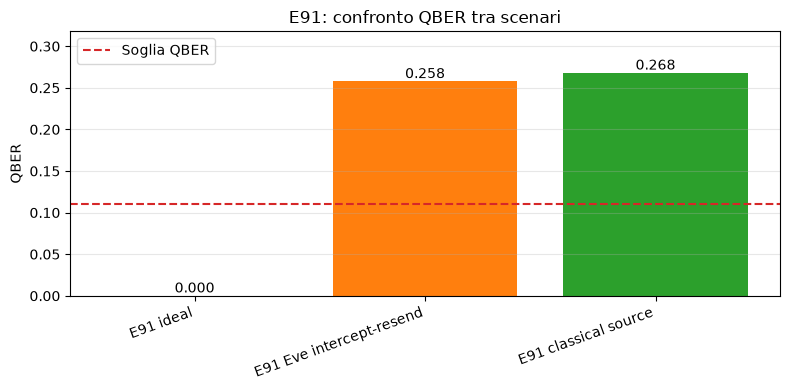

Grafico QBER scenari salvato in: c:\Users\daniz\Desktop\dani uni\Magistrale\Secondo anno\Quantum Computing\Progetto\qkd-cybersecurity-project\results\figures\e91_attack_classical_qber_comparison.png


In [12]:
fig, ax = plt.subplots(figsize=(8, 4))

scenarios = ["E91 ideal", "E91 Eve intercept-resend", "E91 classical source"]
qber_values = qber_comparison_df["qber"]
colors = ["tab:blue", "tab:orange", "tab:green"]

bars = ax.bar(
    scenarios,
    qber_values,
    color=colors,
)

ax.axhline(
    QBER_THRESHOLD,
    linestyle="--",
    color="tab:red",
    label="Soglia QBER",
)

for bar in bars:
    height = bar.get_height()
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        height,
        f"{height:.3f}",
        ha="center",
        va="bottom",
    )

ax.set_title("E91: confronto QBER tra scenari")
ax.set_ylabel("QBER")
ax.set_ylim(0, max(0.3, qber_comparison_df["qber"].max() + 0.05))
ax.grid(axis="y", alpha=0.3)
ax.legend()

plt.xticks(rotation=20, ha="right")
fig.tight_layout()

qber_figure_path = figures_dir / "e91_attack_classical_qber_comparison.png"
fig.savefig(qber_figure_path, dpi=300)
plt.show()

print(f"Grafico QBER scenari salvato in: {qber_figure_path}")


## Grafico CHSH confronto scenari

Usiamo un dot plot: i punti sono risultati simulati, mentre le linee sono soglie teoriche.

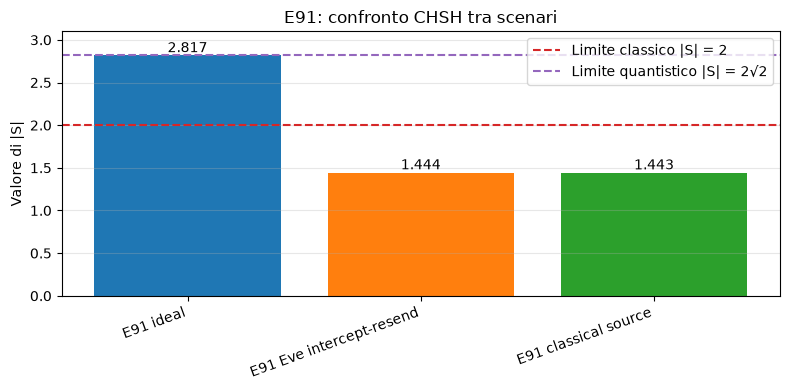

Grafico CHSH scenari salvato in: c:\Users\daniz\Desktop\dani uni\Magistrale\Secondo anno\Quantum Computing\Progetto\qkd-cybersecurity-project\results\figures\e91_attack_classical_chsh_comparison.png


In [13]:
fig, ax = plt.subplots(figsize=(8, 4))

scenarios = ["E91 ideal", "E91 Eve intercept-resend", "E91 classical source"]
abs_s_values = chsh_comparison_df["abs_S"]
colors = ["tab:blue", "tab:orange", "tab:green"]

bars = ax.bar(
    scenarios,
    abs_s_values,
    color=colors,
)

ax.axhline(
    CHSH_CLASSICAL_LIMIT,
    linestyle="--",
    color="tab:red",
    label="Limite classico |S| = 2",
)
ax.axhline(
    CHSH_TSIRELSON_BOUND,
    linestyle="--",
    color="tab:purple",
    label="Limite quantistico |S| = 2\u221a2",
)

for bar in bars:
    height = bar.get_height()
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        height,
        f"{height:.3f}",
        ha="center",
        va="bottom",
    )

ax.set_title("E91: confronto CHSH tra scenari")
ax.set_ylabel("Valore di |S|")
ax.set_ylim(0, 3.1)
ax.grid(axis="y", alpha=0.3)
ax.legend()

plt.xticks(rotation=20, ha="right")
fig.tight_layout()

chsh_figure_path = figures_dir / "e91_attack_classical_chsh_comparison.png"
fig.savefig(chsh_figure_path, dpi=300)
plt.show()

print(f"Grafico CHSH scenari salvato in: {chsh_figure_path}")


## Grafici sweep Eve

Rappresentiamo QBER e |S| al variare della probabilità di intercettazione.

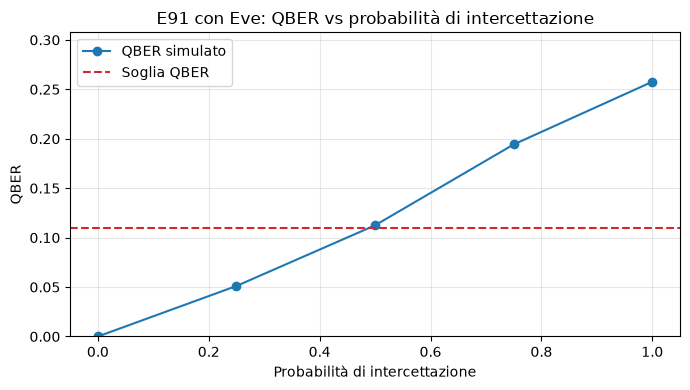

Grafico QBER sweep salvato in: c:\Users\daniz\Desktop\dani uni\Magistrale\Secondo anno\Quantum Computing\Progetto\qkd-cybersecurity-project\results\figures\e91_eve_qber_vs_interception.png


In [14]:
fig, ax = plt.subplots(figsize=(7, 4))

ax.plot(
    sweep_df["intercept_probability"],
    sweep_df["qber"],
    marker="o",
    label="QBER simulato",
)
ax.axhline(
    QBER_THRESHOLD,
    linestyle="--",
    color="tab:red",
    label="Soglia QBER",
)
ax.set_title("E91 con Eve: QBER vs probabilità di intercettazione")
ax.set_xlabel("Probabilità di intercettazione")
ax.set_ylabel("QBER")
ax.set_ylim(0, max(0.3, sweep_df["qber"].max() + 0.05))
ax.grid(True, alpha=0.3)
ax.legend()
fig.tight_layout()

sweep_qber_figure_path = figures_dir / "e91_eve_qber_vs_interception.png"
fig.savefig(sweep_qber_figure_path, dpi=300)
plt.show()

print(f"Grafico QBER sweep salvato in: {sweep_qber_figure_path}")

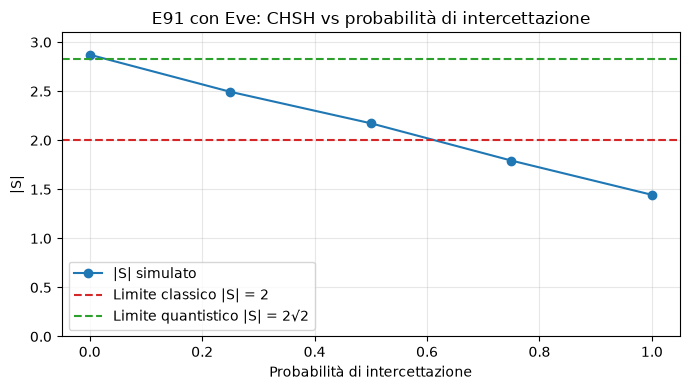

Grafico CHSH sweep salvato in: c:\Users\daniz\Desktop\dani uni\Magistrale\Secondo anno\Quantum Computing\Progetto\qkd-cybersecurity-project\results\figures\e91_eve_chsh_vs_interception.png


In [15]:
fig, ax = plt.subplots(figsize=(7, 4))

ax.plot(
    sweep_df["intercept_probability"],
    sweep_df["abs_S"],
    marker="o",
    label="|S| simulato",
)
ax.axhline(
    CHSH_CLASSICAL_LIMIT,
    linestyle="--",
    color="tab:red",
    label="Limite classico |S| = 2",
)
ax.axhline(
    CHSH_TSIRELSON_BOUND,
    linestyle="--",
    color="tab:green",
    label="Limite quantistico |S| = 2√2",
)
ax.set_title("E91 con Eve: CHSH vs probabilità di intercettazione")
ax.set_xlabel("Probabilità di intercettazione")
ax.set_ylabel("|S|")
ax.set_ylim(0, 3.1)
ax.grid(True, alpha=0.3)
ax.legend()
fig.tight_layout()

sweep_chsh_figure_path = figures_dir / "e91_eve_chsh_vs_interception.png"
fig.savefig(sweep_chsh_figure_path, dpi=300)
plt.show()

print(f"Grafico CHSH sweep salvato in: {sweep_chsh_figure_path}")

## Commento finale

E91 ideale mostra QBER nullo e violazione CHSH. L'attacco intercept-resend di Eve aumenta il QBER e riduce la violazione CHSH.

La sorgente classica può produrre correlazione nei bit, ma non una violazione CHSH robusta. CHSH è quindi il controllo specificamente quantistico che distingue l'entanglement reale da una correlazione classica.